# Estudio de Competencia y Extracción de Datos para Mundo Materno

## 1. Introducción

Mundo Materno es un emprendimiento enfocado en la fabricación y distribución de ropa para mujeres embarazadas, con diferentes tipos de productos cómodos, modernos y adaptados a las necesidades de la maternidad. Sería muy beneficioso para este emprendimiento estudiar y comprender las tendencias de diseño como los rangos de precios, colores y tallas que las futuras madres prefieren.

Para lograr esto se decidió tomar 3 diferentes páginas reconocidas en el sector de la moda y recopilar información útil para mejorar nuestro catálogo, se decidió realizar un análisis de datos a través de web scraping sobre la competencia.

## Tiendas seleccionadas:
- [OhMama](https://www.ohmama.com.co)
- [Saraisa](https://saraisa.co)
- [Carymar](https://www.carymar.co)

## Objetivo del Web Scraping

El objetivo principal del web scraping es:

1. Identificar las categorías de prendas con mayor variedad.
2. Conocer los rangos de precios, colores, tallas y descripciones de los productos ofrecidos por la competencia.
3. Crear un dataset unificado que permita análisis comparativos y estratégicos para Mundo Materno.

---

### 1. Extracción de datos de [Carymar](https://www.carymar.co)

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

base_url = "https://www.carymar.co"
headers = {"User-Agent": "Mozilla/5.0"}

productos = []


response = requests.get(base_url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

colecciones = []
for link in soup.select("a[href*='/collections/']"):
    url = link.get("href")
    if url and "/collections/" in url and "all" not in url:
        url = base_url + url if url.startswith("/") else url
        if url not in colecciones:
            colecciones.append(url)

print(f"✅ Encontradas {len(colecciones)} colecciones")


for coleccion_url in colecciones:
    page = 1
    while True:
        url = coleccion_url if page == 1 else f"{coleccion_url}?page={page}"
        print(f"Scrapeando {url} ...")

        response = requests.get(url, headers=headers)
        soup = BeautifulSoup(response.text, "html.parser")

        items = soup.select("div.product-card")
        if not items:
            break


        for item in items:
            nombre_tag = item.select_one("div.grid-view-item__title")
            nombre = nombre_tag.get_text(strip=True) if nombre_tag else "N/A"

            precio_tag = item.select_one("span.price-item--sale") or item.select_one("span.price-item--regular")
            precio = precio_tag.get_text(strip=True) if precio_tag else "N/A"

            enlace_tag = item.select_one("a")
            enlace = base_url + enlace_tag["href"] if enlace_tag else None

            colores = []
            descripcion = "N/A"


            if enlace:
                try:
                    resp_prod = requests.get(enlace, headers=headers)
                    soup_prod = BeautifulSoup(resp_prod.text, "html.parser")


                    color_tags = soup_prod.select("input[name='Color'][type='radio'] + label") or soup_prod.select("option")
                    colores = [c.get_text(strip=True) for c in color_tags if c.get_text(strip=True)]


                    desc_tag = soup_prod.select_one("div.product-single__description")
                    if desc_tag:
                        descripcion = desc_tag.get_text(strip=True)

                except Exception as e:
                    print(f" Error al extraer {enlace}: {e}")

            productos.append({
                "Categoria": coleccion_url.split("/")[-1],
                "Producto": nombre,
                "Precio": precio,
                "Colores": ", ".join(colores) if colores else "N/A",
                "Descripcion": descripcion,
                "URL": enlace
            })

            time.sleep(1)

        page += 1


df = pd.DataFrame(productos)
df.to_csv("productos_carymar.csv", index=False, encoding="utf-8-sig")

print(f"✅ Se guardaron {len(df)} productos en productos_carymar.csv")


✅ Encontradas 25 colecciones
Scrapeando https://www.carymar.co/collections/blusas ...
Scrapeando https://www.carymar.co/collections/blusas?page=2 ...
Scrapeando https://www.carymar.co/collections/blusas?page=3 ...
Scrapeando https://www.carymar.co/collections/blusas?page=4 ...
Scrapeando https://www.carymar.co/collections/vestidos ...
Scrapeando https://www.carymar.co/collections/vestidos?page=2 ...
Scrapeando https://www.carymar.co/collections/vestidos?page=3 ...
Scrapeando https://www.carymar.co/collections/vestidos?page=4 ...
Scrapeando https://www.carymar.co/collections/jeans ...
Scrapeando https://www.carymar.co/collections/jeans?page=2 ...
Scrapeando https://www.carymar.co/collections/pantalones ...
Scrapeando https://www.carymar.co/collections/pantalones?page=2 ...
Scrapeando https://www.carymar.co/collections/frontpage ...
Scrapeando https://www.carymar.co/collections/frontpage?page=2 ...
Scrapeando https://www.carymar.co/collections/overoles ...
Scrapeando https://www.carymar.

### Extracción Completada
- Ahora tenemos guardados todos los productos de cada sección en un dataset llamado "productos_carymar.csv".  


---
### Dataset productos_carymar.csv

In [ ]:
import pandas as pd

df = pd.read_csv("productos_carymar.csv")
df

,Categoria,Producto,Precio,Colores,Descripcion,URL
0,blusas,Camiseta Polo,$60.000,"S, M, L, XL, Rosa, Blanca, Azul, S / Rosa - A...","Camiseta tipo polo con bordado de cigüeña, cor...",https://www.carymar.co/collections/blusas/prod...
1,blusas,Blusa Carmela,$66.000,"S, M, L, XL, Azul, Rosada, Verde, S / Azul, S ...","La blusa Carmela es una prenda super chic, con...",https://www.carymar.co/collections/blusas/prod...
2,blusas,Blusa straple materna,$62.000,"Blanca, Rosa, Azul, S, M, L, XL, Blanca / S, B...",Blusa straple enresortada adelante y atrás par...,https://www.carymar.co/collections/blusas/prod...
3,blusas,Camiseta materna Huellas,$58.000,"S, M, L, XL, Blanca, Azul Oscuro, Verde, Rosa,...","Camiseta de huellas estampadas, elaborada en t...",https://www.carymar.co/collections/blusas/prod...
4,blusas,Blusa Rafaela,$62.000,"S, M, L, XL, S, M, L, XL",Blusa straple enresortada adelante y atrás par...,https://www.carymar.co/collections/blusas/prod...
...,...,...,...,...,...,...
82,jumper-y-enterizo,Jumper Ana,$90.000,"S, M, L, XL, S, M, L, XL",El jumper Ana es una prenda super fashion para...,https://www.carymar.co/collections/jumper-y-en...
83,jumper-y-enterizo,Jumper Afrodita,$90.000,"S, M, L, XL, S, M - Agotado, L, XL",El jumper Afrodita es una prenda super fashion...,https://www.carymar.co/collections/jumper-y-en...
84,jumper-y-enterizo,Set Luci,$105.000,"S, M, L, XL, Negro, Rosa, Azul Claro, Beige, S...",Este conjunto se ha convertido en uno de nuest...,https://www.carymar.co/collections/jumper-y-en...
85,jumper-y-enterizo,Jumper Loana,$95.000,"S, M, L, XL, Verde, Negro, Chocolate, Azul Cla...","El Jumper Loana, es una prenda super cool para...",https://www.carymar.co/collections/jumper-y-en...


---

### 2. Extracción de datos de [Saraisa](https://saraisa.co)

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

base_url = "https://saraisa.co"
headers = {"User-Agent": "Mozilla/5.0"}

categorias = []
productos = []


resp = requests.get(f"{base_url}/tienda/", headers=headers)
soup = BeautifulSoup(resp.text, "html.parser")

links_categorias = soup.select('a[href*="/categoria-producto/"]')
for link in links_categorias:
    url = link["href"]
    if url not in categorias:
        categorias.append(url)

print(f"✅ Encontradas {len(categorias)} categorías")


for cat_url in categorias:
    print(f"\n🔎 Extrayendo productos de: {cat_url}")
    resp = requests.get(cat_url, headers=headers)
    soup = BeautifulSoup(resp.text, "html.parser")

    items = soup.select("div.nm-shop-loop-title-price")

    for item in items:
        nombre_tag = item.select_one("h3.woocommerce-loop-product__title a")
        nombre = nombre_tag.get_text(strip=True) if nombre_tag else "N/A"
        url_producto = nombre_tag["href"] if nombre_tag else "N/A"

        precio_tag = item.select_one("span.price ins .woocommerce-Price-amount") or item.select_one("span.price .woocommerce-Price-amount")
        precio = precio_tag.get_text(strip=True) if precio_tag else "N/A"

        descripcion = ""
        colores = ""
        estampados = ""
        tallas = ""

        if url_producto != "N/A":
            resp_p = requests.get(url_producto, headers=headers)
            soup_p = BeautifulSoup(resp_p.text, "html.parser")


            desc_tag = soup_p.select_one("div.woocommerce-product-details__short-description")
            if desc_tag:
                descripcion = desc_tag.get_text(strip=True)


            opciones_color = soup_p.select("#pa_colores option")
            colores = ", ".join([o.get("value") for o in opciones_color if o.get("value")])


            opciones_estampado = soup_p.select("#pa_estampado option")
            estampados = ", ".join([o.get("value") for o in opciones_estampado if o.get("value")])


            opciones_tallas = soup_p.select("#pa_tallas option")
            tallas = ", ".join([o.get("value") for o in opciones_tallas if o.get("value")])

            time.sleep(1)

        productos.append({
            "Categoria": cat_url.split("/")[-2],
            "Producto": nombre,
            "Precio": precio,
            "Descripcion": descripcion,
            "Colores": colores,
            "Estampados": estampados,
            "Tallas": tallas,
            "URL": url_producto
        })


df = pd.DataFrame(productos)
df.to_csv("productos_saraisa.csv", index=False, encoding="utf-8-sig")

print(f"\n✅ Se guardaron {len(df)} productos en productos_saraisa.csv")











✅ Encontradas 10 categorías

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/nueva-coleccion/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/vestidos/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/blusas/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/leggings/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/overoles/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/outlet/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/shorts/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/conjunto/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/pantalones/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/enterizos/

✅ Se guardaron 128 productos en productos_saraisa.csv


### Extracción Completada
- Ahora tenemos guardados todos los productos de cada sección en un dataset llamado "productos_saraisa.csv".  


---
### Dataset productos_saraisa.csv


In [ ]:
import pandas as pd

df = pd.read_csv("productos_saraisa.csv")
df

,Categoria,Producto,Precio,Descripcion,Colores,Estampados,Tallas,URL
0,nueva-coleccion,Vestido Selah,"$96,050",Una prenda que acompaña tu historia. Diseñada ...,verde,NaN,"s, m, l, xl, xxl",https://saraisa.co/producto/vestido-selah/
1,nueva-coleccion,Vestido Malia,"$105,400",Un vestido creado para evolucionar contigo. Su...,verde-agua,NaN,"s, m, l, xl, xxl",https://saraisa.co/producto/vestido-malia/
2,nueva-coleccion,Blusa Kaira,"$70,400",Feminidad que se siente y se nota. Un diseño c...,"azul2, blanco, rosado",NaN,"s, m, l, xl, xxl",https://saraisa.co/producto/blusa-kaira/
3,nueva-coleccion,Vestido Celine,"$97,750",Exclusividad en cada detalle. Un vestido pensa...,"azul2, blanco, camel, verde",NaN,"s, m, l, xl, xxl",https://saraisa.co/producto/vestido-celine/
4,nueva-coleccion,Vestido Bruna,"$97,750","Diseñado para mujeres reales, con cortes que s...","rosado, verde-agua",NaN,"s, m, l, xl, xxl",https://saraisa.co/producto/vestido-bruna/
...,...,...,...,...,...,...,...,...
123,enterizos,Overol Xanthe,"$112,800",Un overol versátil diseñado tanto para mujeres...,NaN,NaN,"s, m, xl",https://saraisa.co/producto/overol-xanthe/
124,enterizos,Enterizo Seraphina,"$82,400",¡Descubre nuestro último estilo de enterizo a ...,coral,NaN,s,https://saraisa.co/producto/enterizo-seraphina/
125,enterizos,Enterizo Colette,"$90,000",Nuestro enterizo de pantalón materno está disp...,"camel, negro, palo-rosa",NaN,"s, m, l",https://saraisa.co/producto/enterizo-colette/
126,enterizos,Overol Jean largo,"$95,280",Nuestro overol jean materno es una prenda cómo...,tono-oscuro,NaN,s,https://saraisa.co/producto/overol-jean-largo/


### 2. Extracción de datos de [OhMama](https://www.ohmama.com.co)

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

base_url = "https://www.ohmama.com.co"
headers = {"User-Agent": "Mozilla/5.0"}

categorias = []
productos = []


resp = requests.get(base_url, headers=headers)
soup = BeautifulSoup(resp.text, "html.parser")


links_categorias = soup.select("ul.list-menu li a")
for link in links_categorias:
    url = link.get("href")
    if url and "/collections/" in url:
        url_completa = base_url + url if url.startswith("/") else url
        if url_completa not in categorias:
            categorias.append(url_completa)

print(f"✅ Encontradas {len(categorias)} categorías")


for cat_url in categorias:
    print(f"\n🔎 Extrayendo productos de: {cat_url}")
    resp = requests.get(cat_url, headers=headers)
    soup = BeautifulSoup(resp.text, "html.parser")


    items = soup.select("a.full-unstyled-link")
    for item in items:
        url_producto = item.get("href")
        if not url_producto.startswith("http"):
            url_producto = base_url + url_producto


        resp_p = requests.get(url_producto, headers=headers)
        soup_p = BeautifulSoup(resp_p.text, "html.parser")


        nombre_tag = soup_p.select_one("div.product__title h1")
        nombre = nombre_tag.get_text(strip=True) if nombre_tag else "N/A"


        precio_tag = soup_p.select_one("span.price-item--regular")
        precio = precio_tag.get_text(strip=True) if precio_tag else "N/A"


        desc_tag = soup_p.select_one("div.product__description.rte")
        descripcion = desc_tag.get_text(separator=" ", strip=True) if desc_tag else "N/A"


        colores = []
        for fieldset in soup_p.find_all("fieldset"):
            legend = fieldset.find("legend")
            if legend and "Color" in legend.get_text():
                for input_tag in fieldset.find_all("input", {"type": "radio"}):
                    valor = input_tag.get("value")
                    if valor:
                        colores.append(valor)


        tallas = []
        for fieldset in soup_p.find_all("fieldset"):
            legend = fieldset.find("legend")
            if legend and any(x in legend.get_text() for x in ["Talla", "Tamaño", "Size"]):
                for input_tag in fieldset.find_all("input", {"type": "radio"}):
                    valor = input_tag.get("value")
                    if valor:
                        tallas.append(valor)

        productos.append({
            "Categoria": cat_url.split("/")[-1],
            "Producto": nombre,
            "Precio": precio,
            "Colores": ", ".join(colores) if colores else "N/A",
            "Tallas": ", ".join(tallas) if tallas else "N/A",
            "Descripcion": descripcion,
            "URL": url_producto
        })

        time.sleep(1)


df = pd.DataFrame(productos)
df.to_csv("productos_ohmama.csv", index=False, encoding="utf-8-sig")

print(f"\n✅ Se guardaron {len(df)} productos en productos_ohmama.csv")













✅ Encontradas 9 categorías

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/jeans-maternos

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/blusas-y-camisetas-maternas

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/combos

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/pijamas-lactancia

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/lactancia

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/vestidos-maternos

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/ropa-interior-materna

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/ofertas-especiales

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/compra-todo

✅ Se guardaron 142 productos en productos_ohmama.csv


### Extracción Completada
- Ahora tenemos guardados todos los productos de cada sección en un dataset llamado "productos_ohmama.csv".  


---
### Dataset productos_ohmama.csv

In [ ]:
import pandas as pd

df = pd.read_csv("productos_ohmama.csv")
df

,Categoria,Producto,Precio,Colores,Tallas,Descripcion,URL
0,jeans-maternos,Jean de maternidad negro Julia con cintura evo...,"$139,900.00",NaN,"SM(6-8), L(10), XL(12-14)",Jean de maternidad color negro con cintura evo...,https://www.ohmama.com.co/products/jean-matern...
1,jeans-maternos,Jean de maternidad negro Julia con cintura evo...,"$139,900.00",NaN,"SM(6-8), L(10), XL(12-14)",Jean de maternidad color negro con cintura evo...,https://www.ohmama.com.co/products/jean-matern...
2,jeans-maternos,Jean de maternidad loose fit – banda elástica ...,"$189,900.00","Azul medio, Negro","SM (6-18), LXL (10-12)",Talla SM envíos a partir del martes 17 de febr...,https://www.ohmama.com.co/products/jean-matern...
3,jeans-maternos,Jean de maternidad loose fit – banda elástica ...,"$189,900.00","Azul medio, Negro","SM (6-18), LXL (10-12)",Talla SM envíos a partir del martes 17 de febr...,https://www.ohmama.com.co/products/jean-matern...
4,jeans-maternos,Jogger de maternidad casual cargo – cintura el...,"$139,000.00","Negro, Mocca, Beige",Única (ultra stretch 8-12),Jogger de maternidad en tejido suave con cintu...,https://www.ohmama.com.co/products/jogger-mate...
...,...,...,...,...,...,...,...
137,compra-todo,Jogger de maternidad casual cargo – cintura el...,"$139,000.00","Negro, Mocca, Beige",Única (ultra stretch 8-12),Jogger de maternidad en tejido suave con cintu...,https://www.ohmama.com.co/products/jogger-mate...
138,compra-todo,Pantalón de maternidad palazzo oficina – cintu...,"$119,920.00","Café, Negro raya blanca, Negro",Única (8-10),Pantalón de maternidad tipo palazzo en tejido ...,https://www.ohmama.com.co/products/pantalon-pa...
139,compra-todo,Pantalón de maternidad palazzo oficina – cintu...,"$119,920.00","Café, Negro raya blanca, Negro",Única (8-10),Pantalón de maternidad tipo palazzo en tejido ...,https://www.ohmama.com.co/products/pantalon-pa...
140,compra-todo,Camiseta de maternidad manga larga - pliegues ...,"$89,000.00","Blanco, Negro, Gris, Azul oscuro",Única,Camiseta de maternidad manga larga en algodón ...,https://www.ohmama.com.co/products/camiseta-ma...


### Integración de Datos:
Para poder realizar un análisis completo de la oferta de ropa para mujeres embarazadas, tomamos los tres datasets que creamos mediante web scraping de OhMama, Saraisa y Carymar y los unimos en un solo dataset para poder compararlas todas.

In [ ]:
import pandas as pd


df_carymar = pd.read_csv("productos_carymar.csv", encoding="utf-8-sig")
df_saraisa = pd.read_csv("productos_saraisa.csv", encoding="utf-8-sig")
df_ohmama = pd.read_csv("productos_ohmama.csv", encoding="utf-8-sig")


df_carymar["Tienda"] = "Carymar"
df_saraisa["Tienda"] = "Saraisa"
df_ohmama["Tienda"] = "OhMama"


cols = ["Producto","Categoria",  "Tallas", "Precio", "Colores", "Descripcion", "URL", "Tienda","Estampados",]


def filtrar_columnas(df, columnas):
    existentes = [c for c in columnas if c in df.columns]
    return df[existentes]

df_carymar_sel = filtrar_columnas(df_carymar, cols)
df_saraisa_sel = filtrar_columnas(df_saraisa, cols)
df_ohmama_sel = filtrar_columnas(df_ohmama, cols)


df_todas = pd.concat([df_carymar_sel, df_saraisa_sel, df_ohmama_sel], ignore_index=True)


df_todas.to_csv("productos_todas_las_tiendas.csv", index=False, encoding="utf-8-sig")

print(f"✅ Dataset final generado con {len(df_todas)} productos y guardado en 'productos_todas_las_tiendas.csv'")


✅ Dataset final generado con 357 productos y guardado en 'productos_todas_las_tiendas.csv'


### Dataset Unificado

Ahora toda la informción de las páginas está en un dataset.

In [ ]:
import pandas as pd

df = pd.read_csv("productos_todas_las_tiendas.csv")
df.head(382)

,Producto,Categoria,Precio,Colores,Descripcion,URL,Tienda,Tallas,Estampados
0,Camiseta Polo,blusas,$60.000,"S, M, L, XL, Rosa, Blanca, Azul, S / Rosa - A...","Camiseta tipo polo con bordado de cigüeña, cor...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN,NaN
1,Blusa Carmela,blusas,$66.000,"S, M, L, XL, Azul, Rosada, Verde, S / Azul, S ...","La blusa Carmela es una prenda super chic, con...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN,NaN
2,Blusa straple materna,blusas,$62.000,"Blanca, Rosa, Azul, S, M, L, XL, Blanca / S, B...",Blusa straple enresortada adelante y atrás par...,https://www.carymar.co/collections/blusas/prod...,Carymar,NaN,NaN
3,Camiseta materna Huellas,blusas,$58.000,"S, M, L, XL, Blanca, Azul Oscuro, Verde, Rosa,...","Camiseta de huellas estampadas, elaborada en t...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN,NaN
4,Blusa Rafaela,blusas,$62.000,"S, M, L, XL, S, M, L, XL",Blusa straple enresortada adelante y atrás par...,https://www.carymar.co/collections/blusas/prod...,Carymar,NaN,NaN
...,...,...,...,...,...,...,...,...,...
352,Jogger de maternidad casual cargo – cintura el...,compra-todo,"$139,000.00","Negro, Mocca, Beige",Jogger de maternidad en tejido suave con cintu...,https://www.ohmama.com.co/products/jogger-mate...,OhMama,Única (ultra stretch 8-12),NaN
353,Pantalón de maternidad palazzo oficina – cintu...,compra-todo,"$119,920.00","Café, Negro raya blanca, Negro",Pantalón de maternidad tipo palazzo en tejido ...,https://www.ohmama.com.co/products/pantalon-pa...,OhMama,Única (8-10),NaN
354,Pantalón de maternidad palazzo oficina – cintu...,compra-todo,"$119,920.00","Café, Negro raya blanca, Negro",Pantalón de maternidad tipo palazzo en tejido ...,https://www.ohmama.com.co/products/pantalon-pa...,OhMama,Única (8-10),NaN
355,Camiseta de maternidad manga larga - pliegues ...,compra-todo,"$89,000.00","Blanco, Negro, Gris, Azul oscuro",Camiseta de maternidad manga larga en algodón ...,https://www.ohmama.com.co/products/camiseta-ma...,OhMama,Única,NaN


A lo largo de este proceso, apreciamos que algunas categorías como por ejemplo blusas o jeans, presentaban presencia en más de una página, pero presentaban diferentes denominaciones para un mismo tipo de artículo dependiendo de la página donde estuviéramos. Para ello nos apoyamos en herramientas de inteligencia artificial que permiten establecer categorías equivalentes en cada una de las páginas, para terminar asignándole un nombre único a esta categoría.

Para eso creamos un nuevo dataset consolidado, donde cada categoría incluye el total de las referencias equivalentes en las tres páginas, ahora podemos responder las siguientes preguntas:

* La variedad de artículos por tipo de prenda.
* Los rangos de precios por categoría.
* La categoría de prendas que tenga los precios más caros.


In [ ]:
import pandas as pd


df = pd.read_csv("productos_todas_las_tiendas.csv", encoding="utf-8-sig")


df['Precio'] = df['Precio'].str.replace(r'[^\d]', '', regex=True).astype(int)


df = df[["Producto", "Tallas", "Precio", "Colores", "Descripcion", "URL", "Tienda","Estampados"]]
df.head()

,Producto,Tallas,Precio,Colores,Descripcion,URL,Tienda,Estampados
0,Camiseta Polo,NaN,60000,"S, M, L, XL, Rosa, Blanca, Azul, S / Rosa - A...","Camiseta tipo polo con bordado de cigüeña, cor...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN
1,Blusa Carmela,NaN,66000,"S, M, L, XL, Azul, Rosada, Verde, S / Azul, S ...","La blusa Carmela es una prenda super chic, con...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN
2,Blusa straple materna,NaN,62000,"Blanca, Rosa, Azul, S, M, L, XL, Blanca / S, B...",Blusa straple enresortada adelante y atrás par...,https://www.carymar.co/collections/blusas/prod...,Carymar,NaN
3,Camiseta materna Huellas,NaN,58000,"S, M, L, XL, Blanca, Azul Oscuro, Verde, Rosa,...","Camiseta de huellas estampadas, elaborada en t...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN
4,Blusa Rafaela,NaN,62000,"S, M, L, XL, S, M, L, XL",Blusa straple enresortada adelante y atrás par...,https://www.carymar.co/collections/blusas/prod...,Carymar,NaN


###¿Cúales son los tipos de prenda que más varían por Categoría?

/tmp/ipython-input-3157090679.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=productos_por_tienda.index, y=productos_por_tienda.values, palette="pastel")


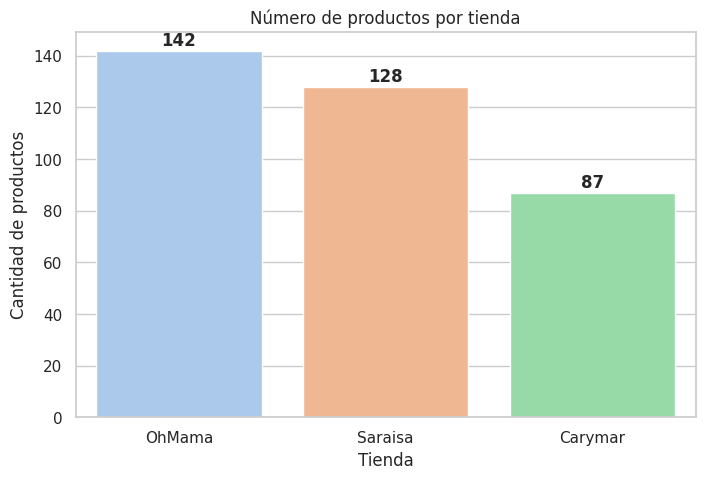

/tmp/ipython-input-3157090679.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=productos_por_categoria.index, y=productos_por_categoria.values, palette="muted")


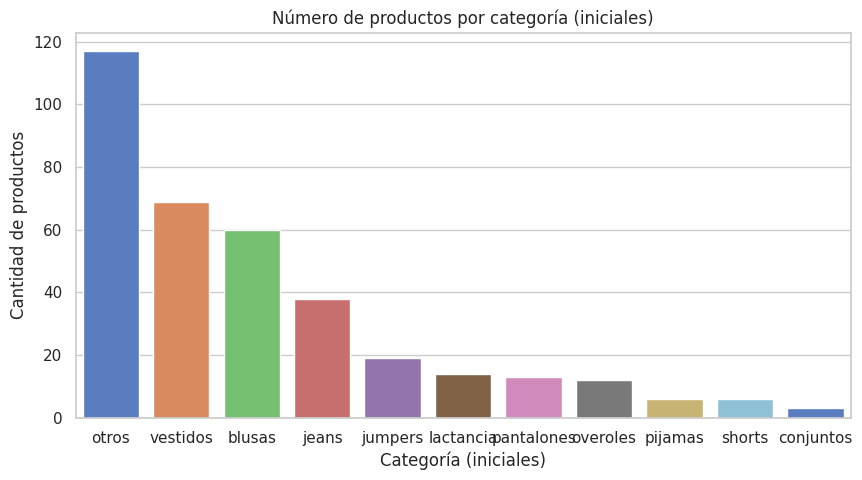

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
df = pd.read_csv("productos_todas_las_tiendas.csv", encoding="utf-8-sig")

# Función para renombrar categorías según sus iniciales
def categoria_inicial(cat):
    cat = str(cat).lower()
    if cat.startswith("blusa"):
        return "blusas"
    elif cat.startswith("vestido"):
        return "vestidos"
    elif cat.startswith("jean"):
        return "jeans"
    elif cat.startswith("pantalon") or cat.startswith("pantalones"):
        return "pantalones"
    elif cat.startswith("short"):
        return "shorts"
    elif cat.startswith("jumper") or cat.startswith("enterizo"):
        return "jumpers"
    elif cat.startswith("overol"):
        return "overoles"
    elif cat.startswith("conjunto"):
        return "conjuntos"
    elif cat.startswith("pijamas"):
        return "pijamas"
    elif cat.startswith("lactancia"):
        return "lactancia"
    else:
        return "otros"



df["Categoria_ini"] = df["Categoria"].apply(categoria_inicial)


productos_por_tienda = df.groupby("Tienda")["Producto"].count().sort_values(ascending=False)


productos_por_categoria = df.groupby("Categoria_ini")["Producto"].count().sort_values(ascending=False)


sns.set(style="whitegrid")


plt.figure(figsize=(8,5))
sns.barplot(x=productos_por_tienda.index, y=productos_por_tienda.values, palette="pastel")
plt.title("Número de productos por tienda")
plt.ylabel("Cantidad de productos")
plt.xlabel("Tienda")
for i, v in enumerate(productos_por_tienda.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.show()


plt.figure(figsize=(10,5))
sns.barplot(x=productos_por_categoria.index, y=productos_por_categoria.values, palette="muted")
plt.title("Número de productos por categoría (iniciales)")
plt.ylabel("Cantidad de productos")
plt.xlabel("Categoría (iniciales)")

plt.show()


###¿Cúales son los rangos de precio por Categoría?

###¿Cúal es la categoría con los precios más altos?

<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-3852967022.py:9: SyntaxWarning: invalid escape sequence '\$'
  df['Precio_num'] = df['Precio'].replace({'\$':'', ',':''}, regex=True).astype(float)
/tmp/ipython-input-3852967022.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promedios.index, y=promedios.values, palette="magma")


 Promedio de precios por categoría:
Categoria_ini
pijamas       116566.666667
jeans         106545.684211
otros          96826.478632
conjuntos      93600.000000
lactancia      85614.285714
vestidos       71254.869565
overoles       54822.916667
pantalones     40362.769231
blusas         39483.683333
jumpers        35263.105263
shorts         25443.666667
Name: Precio_num, dtype: float64


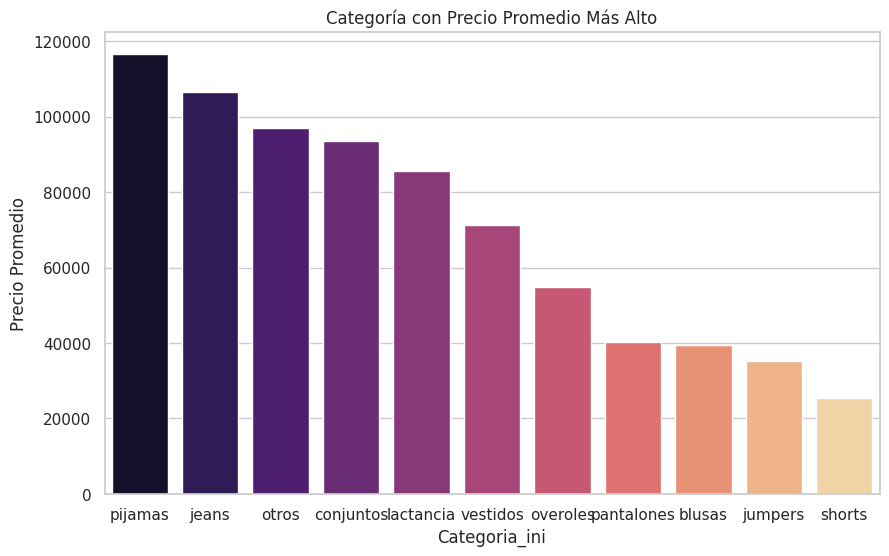

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("productos_todas_las_tiendas.csv", encoding="utf-8-sig")


df['Precio_num'] = df['Precio'].replace({'\$':'', ',':''}, regex=True).astype(float)


def categoria_inicial(cat):
    cat = str(cat).lower()
    if cat.startswith("blusa"):
        return "blusas"
    elif cat.startswith("vestido"):
        return "vestidos"
    elif cat.startswith("jean"):
        return "jeans"
    elif cat.startswith("pantalon") or cat.startswith("pantalones"):
        return "pantalones"
    elif cat.startswith("short"):
        return "shorts"
    elif cat.startswith("jumper") or cat.startswith("enterizo"):
        return "jumpers"
    elif cat.startswith("overol"):
        return "overoles"
    elif cat.startswith("conjunto"):
        return "conjuntos"
    elif cat.startswith("pijamas"):
        return "pijamas"
    elif cat.startswith("lactancia"):
        return "lactancia"
    else:
        return "otros"

df["Categoria_ini"] = df["Categoria"].apply(categoria_inicial)


promedios = df.groupby("Categoria_ini")['Precio_num'].mean().sort_values(ascending=False)

print(" Promedio de precios por categoría:")
print(promedios)


plt.figure(figsize=(10,6))
sns.barplot(x=promedios.index, y=promedios.values, palette="magma")
plt.title("Categoría con Precio Promedio Más Alto")
plt.ylabel("Precio Promedio")
plt.show()


### Conclusión


En conclusión pudimos determinar que las prendas que presentan mayor variación en cuanto a diseño son las blusas, ya que hay 154 tipos de blusas diferentes en todo el dataset y gracias al último gráfico pudimos visualizar la variación de los precios en las diferentes categorías y determinar cuáles son los tipos de prendas más caras y más baratas.

En este momento realizamos el proceso así pero en un futuro pensamos usar procesamiento de lenguaje natural para aplicarlo en la columna "otros" para ver todos los elementos que están dentro de ella y categorizarlos correctamente.


In [ ]:
from google.colab import files

files.download('productos_todas_las_tiendas.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>